In [1]:
from neural_priors.utils.data import Subject
from neural_priors.encoding_model.fit_model import get_paradigm, get_model
import pandas as pd
from braincoder.utils import get_rsq
import seaborn as sns

In [3]:
model = get_model(35)

model

In [2]:
get_model(35).parameter_labels

['mu_narrow',
 'delta_wide',
 'lower_bound_range',
 'baseline',
 'sd',
 'amplitude_narrow',
 'amplitude_alpha',
 'amplitude_beta']

In [164]:
paradigm

x range
subject session run trial_nr            
12      1       1   1         39.0  Wide
                    2         34.0  Wide
                    3         11.0  Wide
                    4         27.0  Wide
                    5         34.0  Wide
...                            ...   ...
        2       8   26        37.0  Wide
                    27        22.0  Wide
                    28        11.0  Wide
                    29        25.0  Wide
                    30        17.0  Wide

[480 rows x 2 columns]

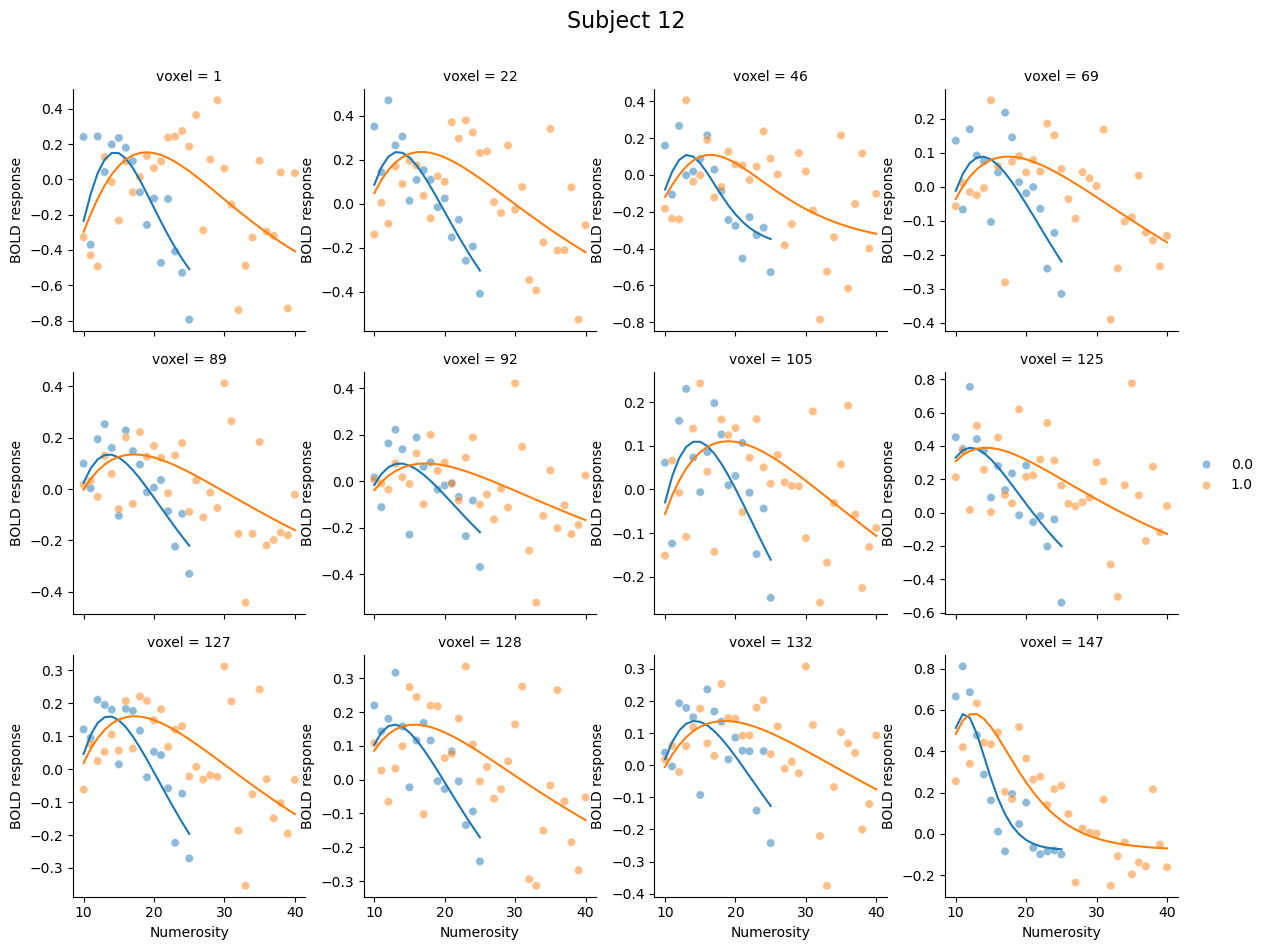

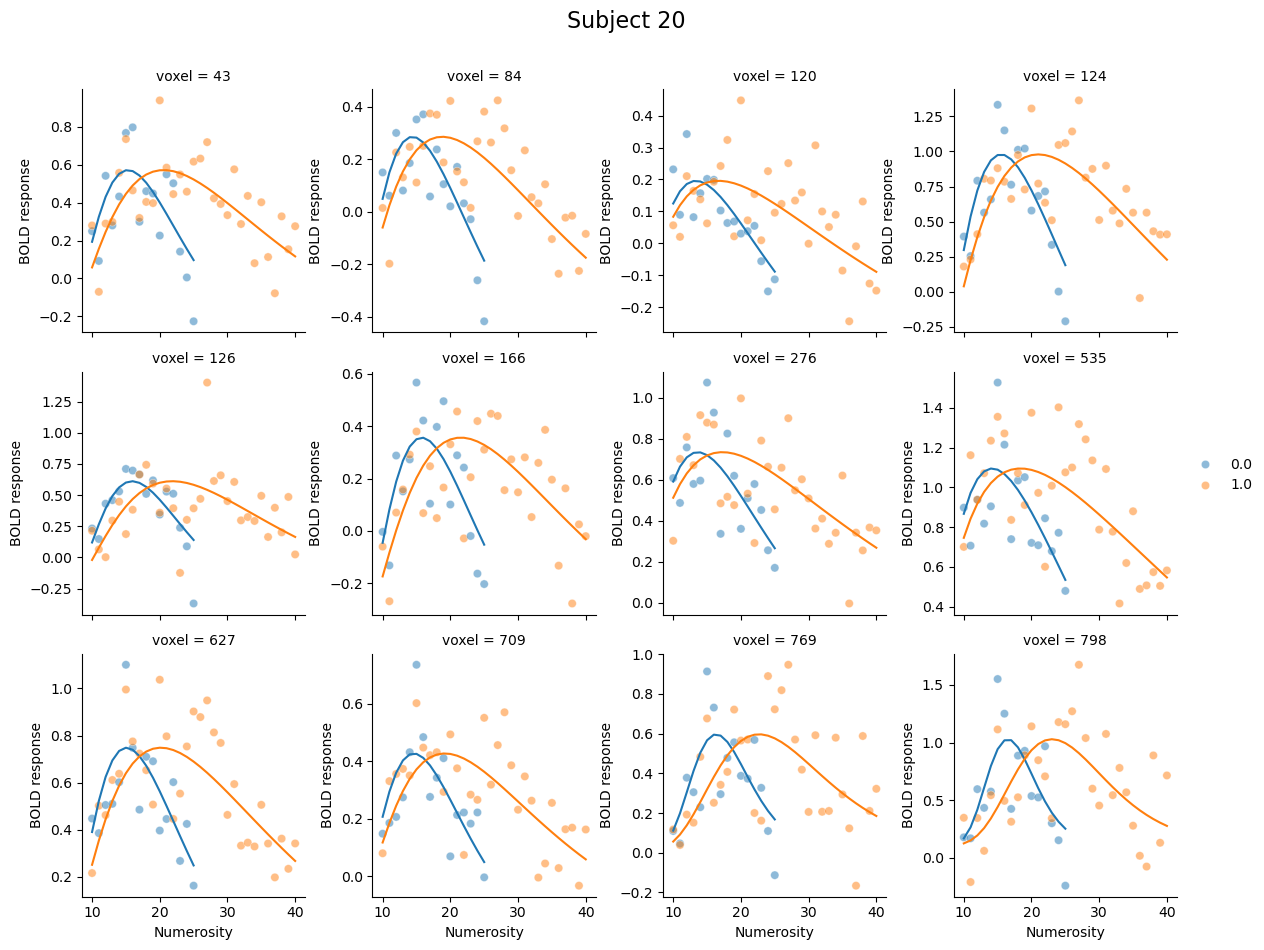

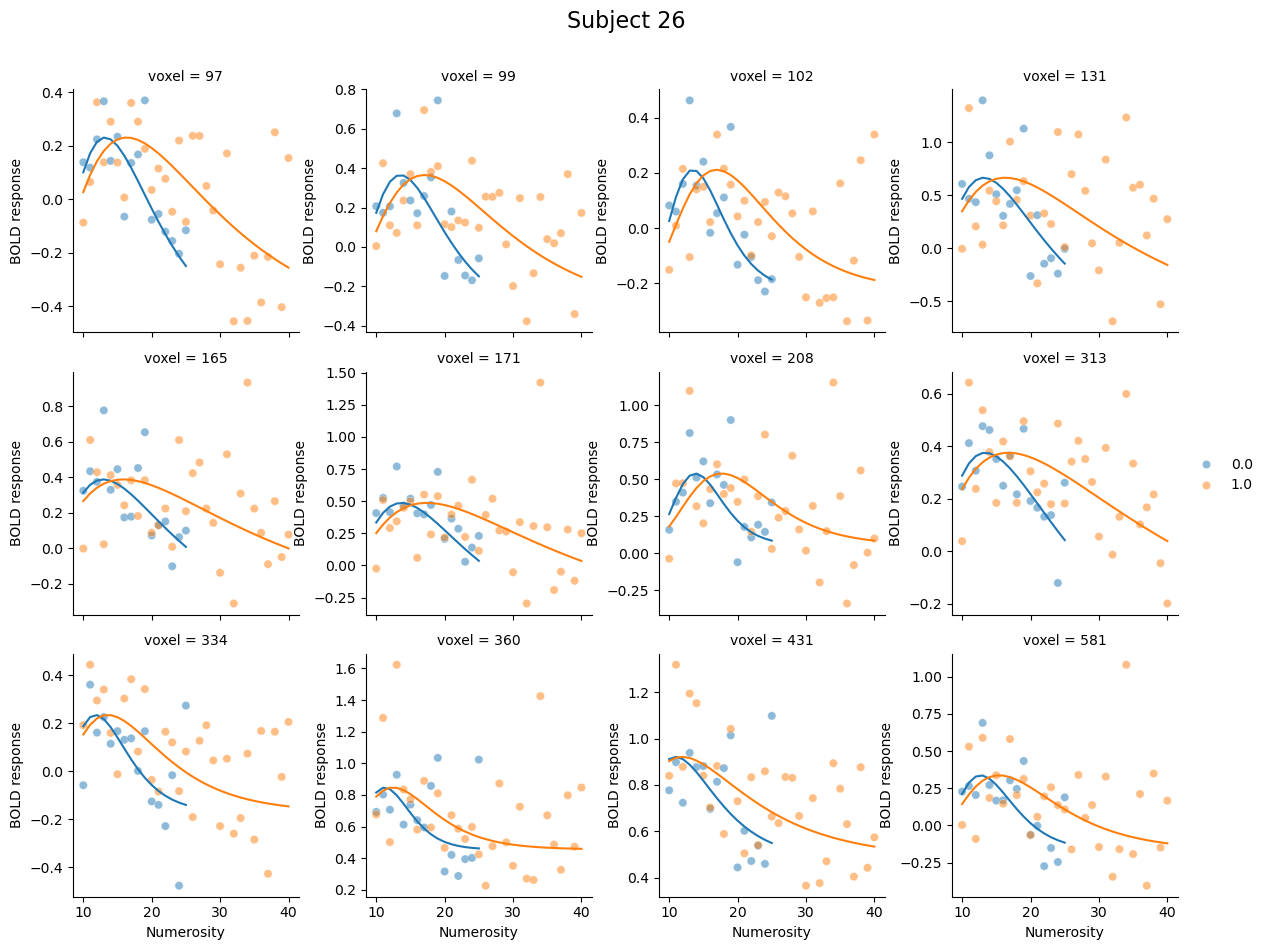

In [176]:
top_subjects = [12, 20, 26]


for sub_id in top_subjects:
    sub = Subject(sub_id)
    data = sub.get_single_trial_estimates(session=None, roi='NPCr', smoothed=True)
    paradigm = get_paradigm(sub)



    model = get_model(15)

    pars = sub.get_prf_parameters_volume(15, roi='NPCr', raw=True, smoothed=True)

    pred = model.predict(paradigm=paradigm, parameters=pars)
    pred.index = pd.MultiIndex.from_frame(paradigm)
    pred.columns.name = 'voxel'

    data= pd.DataFrame(data, index=pred.index, columns=pred.columns)
    data.set_index(pred.index, inplace=True)

    r2 = get_rsq(data, pred)
    # import seaborn as sns
    # sns.histplot(r2)

    tmp = data.groupby(['x', 'range']).mean().stack().to_frame('data').join(pred.groupby(['x', 'range']).mean().stack().to_frame('prediction'))

    top_voxels = r2[pars['mu_narrow'] > 10.9].sort_values(ascending=False).index[:60:5]
    g = sns.FacetGrid(tmp.loc[(slice(None), slice(None), top_voxels)].reset_index(), height=3
                    , col='voxel', col_wrap=4, sharey=False)
    # g.map(sns.scatterplot, 'prediction', 'data')

    g.map_dataframe(sns.lineplot, x='x', y='prediction', hue='range')

    g.map_dataframe(sns.scatterplot, x='x', y='data', hue='range', alpha=0.5)

    g.add_legend()


    g.fig.suptitle(f'Subject {sub_id}', fontsize=16, y=1.05)

    g.set(xlabel='Numerosity', ylabel='BOLD response')



In [169]:
    tmp = data.groupby(['x', 'range']).mean().stack().to_frame('data').join(pred.groupby(['x', 'range']).mean().stack().to_frame('prediction'))

    # Map 2nd index level 'range' to Narrow/Wide
    tmp['range'] = tmp.index.get_level_values('range').map({0: 'Narrow', 1: 'Wide'})

In [180]:
paradigm.groupby(['x', 'range']).size()

x     range
10.0  0.0      13
      1.0      10
11.0  0.0      13
      1.0       8
12.0  0.0      21
      1.0       5
13.0  0.0      14
      1.0       4
14.0  0.0      18
      1.0       8
15.0  0.0      19
      1.0       9
16.0  0.0      12
      1.0       5
17.0  0.0      15
      1.0      15
18.0  0.0      18
      1.0      10
19.0  0.0       7
      1.0       8
20.0  0.0      19
      1.0      12
21.0  0.0      23
      1.0       5
22.0  0.0      10
      1.0       8
23.0  0.0      18
      1.0       8
24.0  0.0      13
      1.0       9
25.0  0.0       7
      1.0       6
26.0  1.0      12
27.0  1.0       7
28.0  1.0       5
29.0  1.0      10
30.0  1.0      10
31.0  1.0      10
32.0  1.0      10
33.0  1.0      14
34.0  1.0       1
35.0  1.0       5
36.0  1.0       5
37.0  1.0       5
38.0  1.0       4
39.0  1.0      10
40.0  1.0       2
dtype: int64

In [168]:
tmp.index

MultiIndex([(10.0, 0.0,   0, 'Narrow'),
            (10.0, 0.0,   1, 'Narrow'),
            (10.0, 0.0,   2, 'Narrow'),
            (10.0, 0.0,   3, 'Narrow'),
            (10.0, 0.0,   4, 'Narrow'),
            (10.0, 0.0,   5, 'Narrow'),
            (10.0, 0.0,   6, 'Narrow'),
            (10.0, 0.0,   7, 'Narrow'),
            (10.0, 0.0,   8, 'Narrow'),
            (10.0, 0.0,   9, 'Narrow'),
            ...
            (40.0, 1.0, 880,   'Wide'),
            (40.0, 1.0, 881,   'Wide'),
            (40.0, 1.0, 882,   'Wide'),
            (40.0, 1.0, 883,   'Wide'),
            (40.0, 1.0, 884,   'Wide'),
            (40.0, 1.0, 885,   'Wide'),
            (40.0, 1.0, 886,   'Wide'),
            (40.0, 1.0, 887,   'Wide'),
            (40.0, 1.0, 888,   'Wide'),
            (40.0, 1.0, 889,   'Wide')],
           names=['x', 'range', 'voxel', 'range'], length=41830)

<Axes: xlabel='r2', ylabel='Count'>

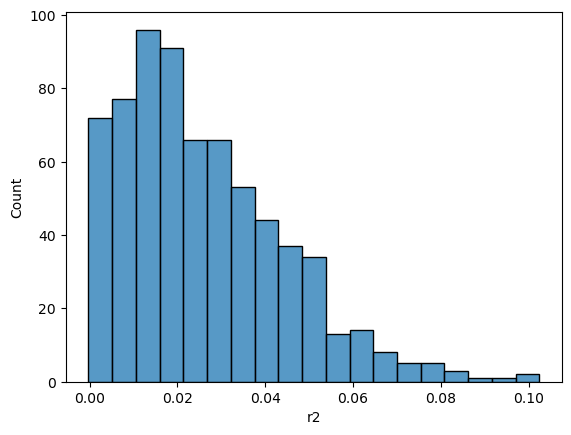

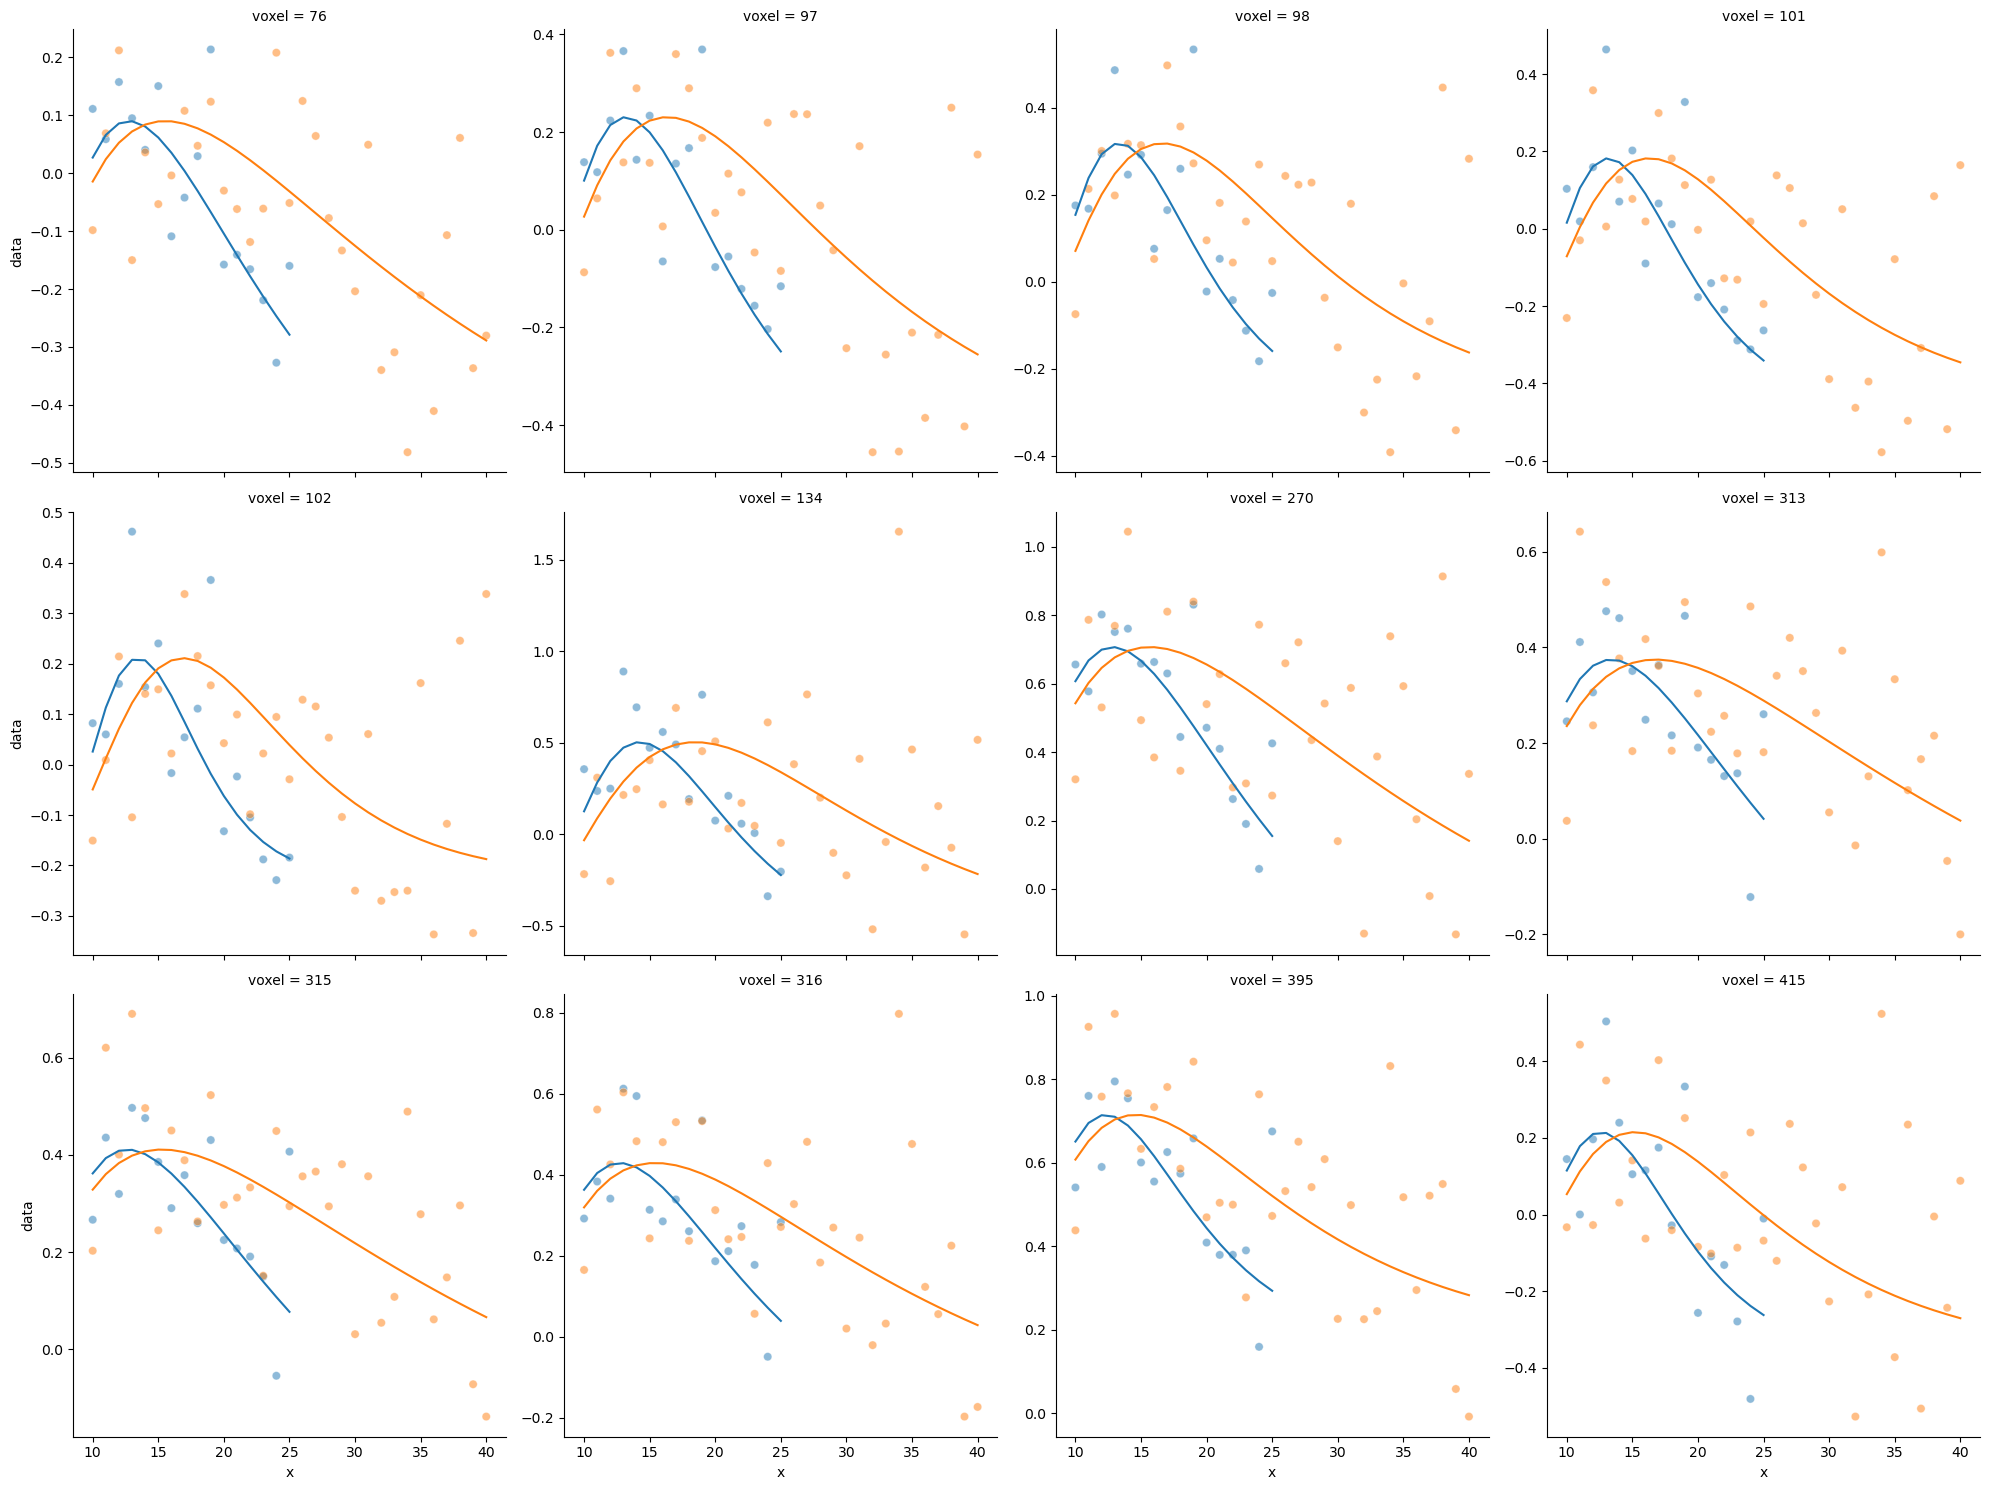